In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df=pd.read_csv(r"C:\Users\sandr\Downloads\healthcare_dataset.csv\healthcare_dataset.csv")
print(df)

                    Name  Age  Gender Blood Type Medical Condition  \
0          Bobby JacksOn   30    Male         B-            Cancer   
1           LesLie TErRy   62    Male         A+           Obesity   
2            DaNnY sMitH   76  Female         A-           Obesity   
3           andrEw waTtS   28  Female         O+          Diabetes   
4          adrIENNE bEll   43  Female        AB+            Cancer   
...                  ...  ...     ...        ...               ...   
55495  eLIZABeTH jaCkSOn   42  Female         O+            Asthma   
55496         KYle pEREz   61  Female        AB-           Obesity   
55497       HEATher WaNG   38  Female         B+      Hypertension   
55498     JENniFER JOneS   43    Male         O-         Arthritis   
55499       jAMES GARCiA   53  Female         O+         Arthritis   

      Date of Admission            Doctor                      Hospital  \
0            2024-01-31     Matthew Smith               Sons and Miller   
1        

In [17]:
df.shape


(55500, 15)

In [15]:
df.describe(include="all")

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
count,55500,55500.000000,55500,55500,55500,55500,55500,55500,55500,55500.000000,55500.000000,55500,55500,55500,55500
unique,49992,NaN,2,8,6,1827,40341,39876,5,NaN,NaN,3,1856,5,3
top,DAvId muNoZ,NaN,Male,A-,Arthritis,2024-03-16,Michael Smith,LLC Smith,Cigna,NaN,NaN,Elective,2020-03-15,Lipitor,Abnormal
freq,3,NaN,27774,6969,9308,50,27,44,11249,NaN,NaN,18655,53,11140,18627
mean,NaN,51.539459,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25539.316097,301.134829,NaN,NaN,NaN,NaN
std,NaN,19.602454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14211.454431,115.243069,NaN,NaN,NaN,NaN
min,NaN,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2008.492140,101.000000,NaN,NaN,NaN,NaN
25%,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13241.224652,202.000000,NaN,NaN,NaN,NaN
50%,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25538.069376,302.000000,NaN,NaN,NaN,NaN
75%,NaN,68.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37820.508436,401.000000,NaN,NaN,NaN,NaN


In [12]:
df.dtypes

Name                      str
Age                     int64
Gender                    str
Blood Type                str
Medical Condition         str
Date of Admission         str
Doctor                    str
Hospital                  str
Insurance Provider        str
Billing Amount        float64
Room Number             int64
Admission Type            str
Discharge Date            str
Medication                str
Test Results              str
dtype: object

In [13]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [16]:
df.ndim

2

In [18]:
df.size

832500

In [21]:
# What is the average age of the patients?
print(df["Age"].mean())

51.53945945945946


In [22]:
# How many patients belong to each blood type?
df["Blood Type"].value_counts()

Blood Type
A-     6969
A+     6956
AB+    6947
AB-    6945
B+     6945
B-     6944
O+     6917
O-     6877
Name: count, dtype: int64

In [25]:
# What is the maximum age of the patients?
print(df["Age"].max())

89


In [26]:
# How many patients are there in each gender?
df["Gender"].value_counts()

Gender
Male      27774
Female    27726
Name: count, dtype: int64

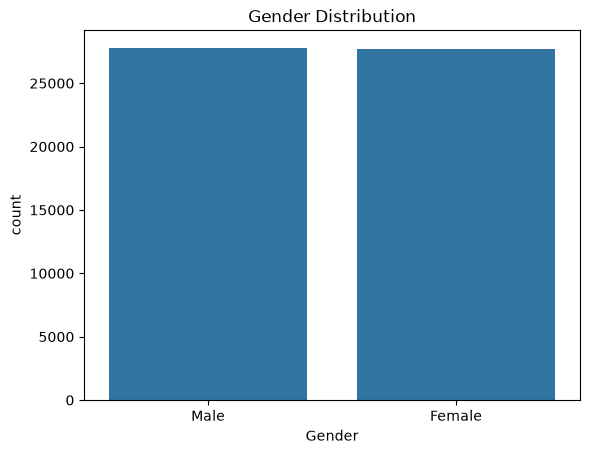

In [27]:
# How are patients distributed by gender?
sns.countplot(data=df, x="Gender")
plt.title("Gender Distribution")
plt.show()

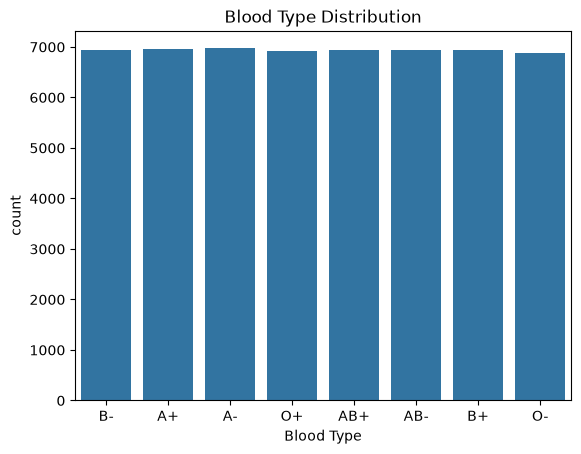

In [30]:
# How are patients distributed across different blood types?
sns.countplot(data=df, x="Blood Type")
plt.title("Blood Type Distribution")
plt.show()

Text(0.5, 1.0, 'Age Distribution')

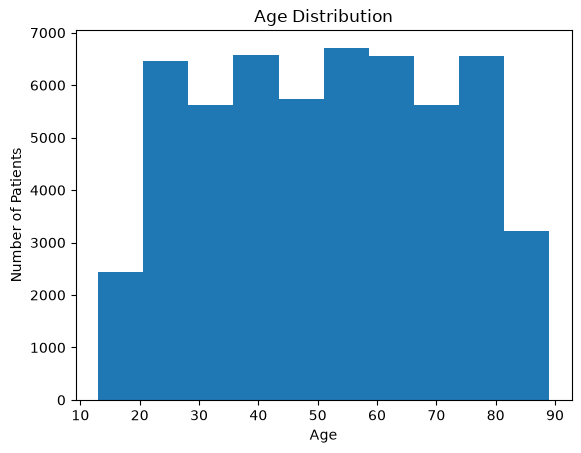

In [32]:
# How are patients distributed by age?
plt.hist(df["Age"], bins=10)
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Age Distribution")


In [33]:
# Which medical condition is most common among the patients?
df["Medical Condition"].value_counts().head(1)

Medical Condition
Arthritis    9308
Name: count, dtype: int64

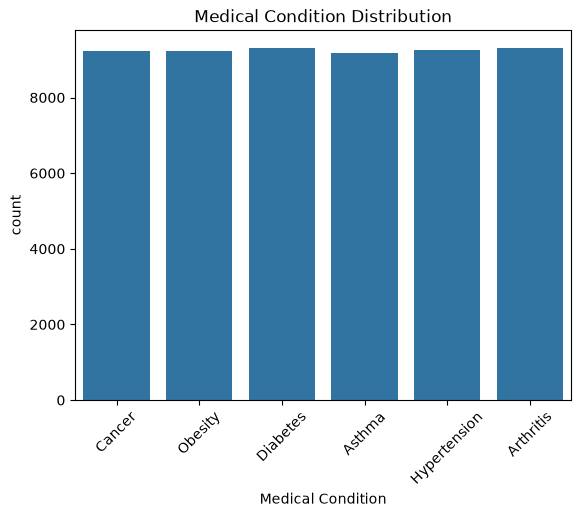

In [34]:
# How are patients distributed across medical conditions?
sns.countplot(data=df, x="Medical Condition")
plt.title("Medical Condition Distribution")
plt.xticks(rotation=45)
plt.show()

In [35]:
# What is the average billing amount?
df["Billing Amount"].mean()

np.float64(25539.316097211795)

In [36]:
# What is the max billing amount?
df["Billing Amount"].max()

np.float64(52764.276736469175)

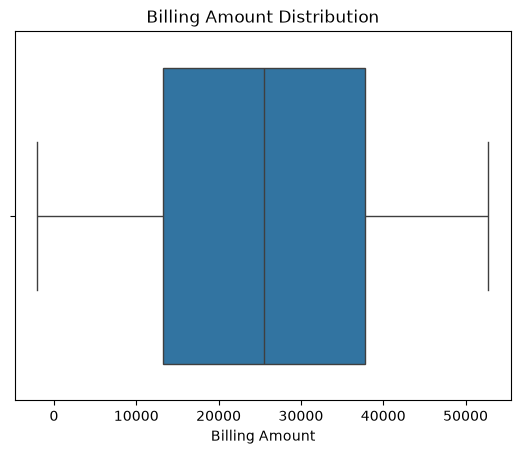

In [ ]:

# How are the billing amounts distributed?
sns.boxplot(x=df["Billing Amount"])
plt.xlabel("Billing Amount")
plt.title("Billing Amount Distribution")
plt.show()

In [39]:
# What is the average billing amount for each medical condition?
df.groupby("Medical Condition")["Billing Amount"].mean()

Medical Condition
Arthritis       25497.327056
Asthma          25635.249359
Cancer          25161.792707
Diabetes        25638.405577
Hypertension    25497.095761
Obesity         25805.971259
Name: Billing Amount, dtype: float64

In [44]:
# Which medical condition has the highest average billing amount?
df.groupby("Medical Condition")["Billing Amount"].mean().sort_values(ascending=False).head(1)

Medical Condition
Obesity    25805.971259
Name: Billing Amount, dtype: float64

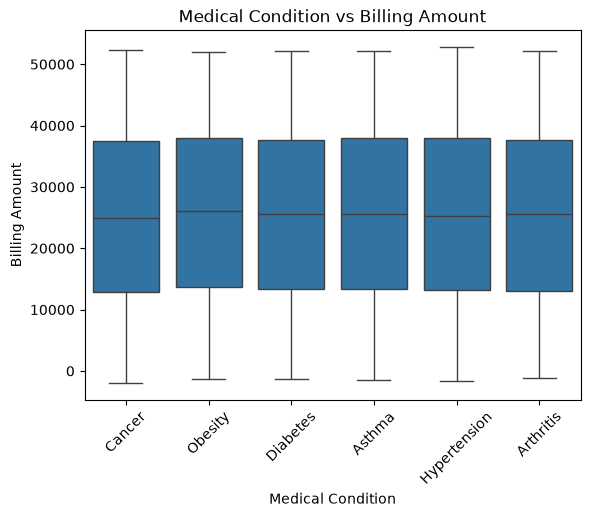

In [45]:
# How does billing amount vary across medical conditions?
sns.boxplot(data=df, x="Medical Condition", y="Billing Amount")
plt.title("Medical Condition vs Billing Amount")
plt.xticks(rotation=45)
plt.show()

In [46]:
# How many patients use each medication?
df["Medication"].value_counts()

Medication
Lipitor        11140
Ibuprofen      11127
Aspirin        11094
Paracetamol    11071
Penicillin     11068
Name: count, dtype: int64

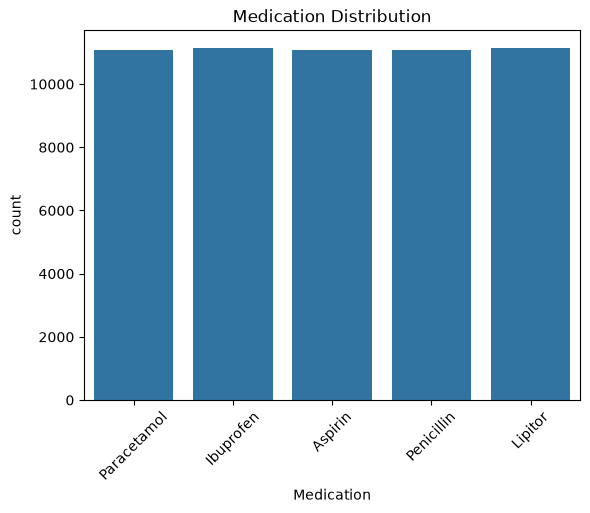

In [47]:
# How are medications distributed among patients?
sns.countplot(data=df, x="Medication")
plt.title("Medication Distribution")
plt.xticks(rotation=45)
plt.show()

In [49]:
df["Medication"].value_counts()

Medication
Lipitor        11140
Ibuprofen      11127
Aspirin        11094
Paracetamol    11071
Penicillin     11068
Name: count, dtype: int64

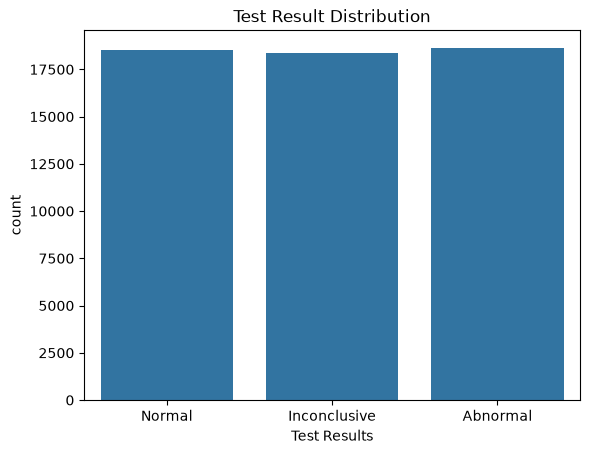

In [50]:
# How are test results distributed among patients?
sns.countplot(data=df, x="Test Results")
plt.title("Test Result Distribution")
plt.show()

In [51]:
# Which 10 hospitals have the highest number of patients?
df["Hospital"].value_counts().head(10)

Hospital
LLC Smith      44
Ltd Smith      39
Johnson PLC    38
Smith Ltd      37
Smith PLC      36
Smith Group    36
Johnson Inc    35
Smith Inc      34
Smith LLC      32
Group Smith    32
Name: count, dtype: int64

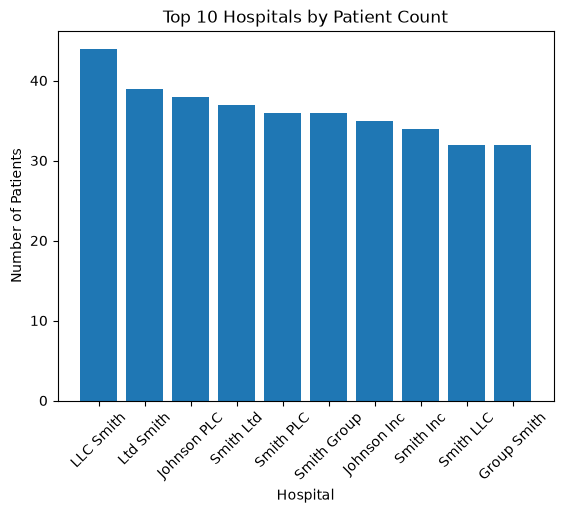

In [53]:
# What is the patient count of the top 10 hospitals?
hospital_count = df["Hospital"].value_counts().head(10)

plt.bar(hospital_count.index, hospital_count.values)
plt.title("Top 10 Hospitals by Patient Count")
plt.xlabel("Hospital")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()

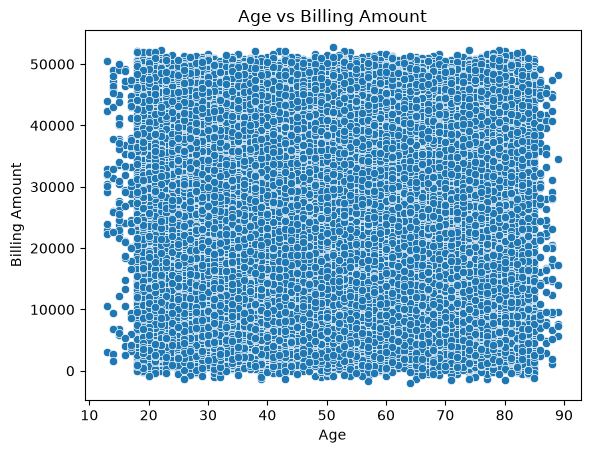

In [54]:
# Is there a relationship between patient age and billing amount?
sns.scatterplot(data=df, x="Age", y="Billing Amount")
plt.title("Age vs Billing Amount")
plt.show()

In [55]:
# What is the correlation between age and billing amount?
df["Age"].corr(df["Billing Amount"])

np.float64(-0.0038319421186176704)

In [56]:
# What is the correlation between the numerical variables?
df.corr(numeric_only=True)

,Age,Billing Amount,Room Number
Age,1.000000,-0.003832,-0.000720
Billing Amount,-0.003832,1.000000,-0.002943
Room Number,-0.000720,-0.002943,1.000000


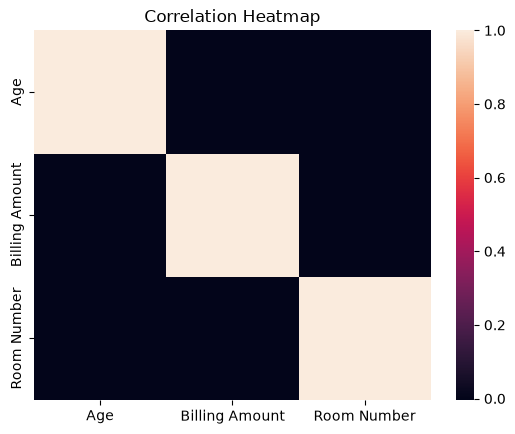

In [59]:
# What is the correlation between the numerical variables?
sns.heatmap(df.corr(numeric_only=True))
plt.title("Correlation Heatmap")
plt.show()

Gender
Male      27774
Female    27726
Name: count, dtype: int64


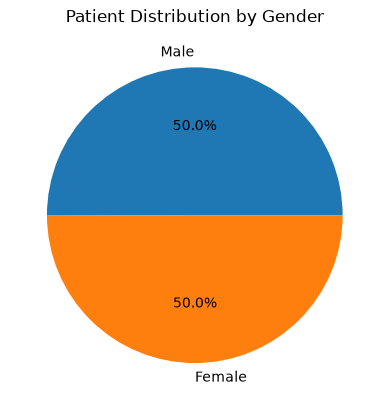

In [63]:
# What is the distribution of patients by gender?
gender_count = df["Gender"].value_counts()
print(gender_count)
plt.pie(gender_count.values, labels=gender_count.index, autopct="%1.1f%%")
plt.title("Patient Distribution by Gender")
plt.show()